In [15]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [16]:
import os

folder = r"D:\MTECH\MTECH_SEM\L2A_T39QYG_A054858_20251223T070332\IMG_DATA\R20m"

for f in os.listdir(folder):
    print(f)

T39QYG_20251223T070331_AOT_20m.jp2
T39QYG_20251223T070331_B01_20m.jp2
T39QYG_20251223T070331_B02_20m.jp2
T39QYG_20251223T070331_B03_20m.jp2
T39QYG_20251223T070331_B04_20m.jp2
T39QYG_20251223T070331_B05_20m.jp2
T39QYG_20251223T070331_B06_20m.jp2
T39QYG_20251223T070331_B07_20m.jp2
T39QYG_20251223T070331_B11_20m.jp2
T39QYG_20251223T070331_B12_20m.jp2
T39QYG_20251223T070331_B8A_20m.jp2
T39QYG_20251223T070331_SCL_20m.jp2
T39QYG_20251223T070331_TCI_20m.jp2
T39QYG_20251223T070331_WVP_20m.jp2


In [17]:
# Sentinel-2 wavelengths (nm)
wavelengths = [443,490,560,665,705,740,783,865,1610,2190]

In [18]:
import rasterio

folder = r"D:\MTECH\MTECH_SEM\L2A_T39QYG_A054858_20251223T070332\IMG_DATA\R20m"

band_files = [
    folder + r"\T39QYG_20251223T070331_B01_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B02_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B03_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B04_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B05_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B06_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B07_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B8A_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B11_20m.jp2",
    folder + r"\T39QYG_20251223T070331_B12_20m.jp2"
]

bands = []

for file in band_files:
    with rasterio.open(file) as src:
        bands.append(src.read(1))

print("All bands loaded successfully!")
print("Number of bands =", len(bands))

All bands loaded successfully!
Number of bands = 10


In [19]:
print(bands[0].shape)

(5490, 5490)


In [21]:
print(len(bands))

10


In [22]:
print(type(bands))
print(len(bands))
print(bands[0].shape)

<class 'list'>
10
(5490, 5490)


In [23]:
print(bands[0][2500,2500])

3228


In [24]:
def get_signature(pixel):

    row, col = pixel

    values = []

    for band in bands:
        values.append(float(band[row, col]) / 10000)

    return values


builtup = get_signature((2500,2500))
industrial = get_signature((3000,2800))
sand = get_signature((3500,1500))

print("Built-up =", builtup)
print("Industrial =", industrial)
print("Sand =", sand)

Built-up = [0.3228, 0.369, 0.4514, 0.5346, 0.5811, 0.5825, 0.5996, 0.6151, 0.7262, 0.6132]
Industrial = [0.2886, 0.3342, 0.4203, 0.5029, 0.5473, 0.5486, 0.5608, 0.5779, 0.6964, 0.6214]
Sand = [0.2535, 0.2854, 0.3816, 0.4933, 0.5382, 0.5463, 0.5595, 0.5674, 0.6937, 0.6549]


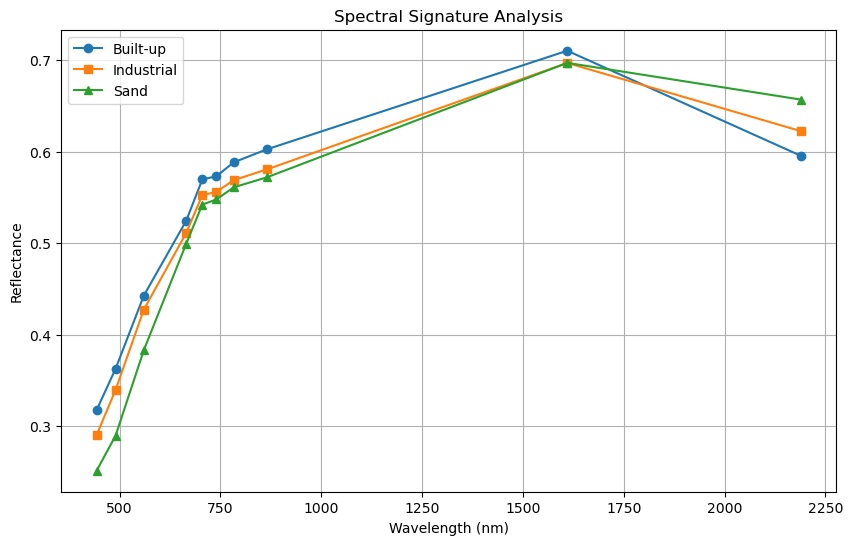

In [28]:
wavelengths = [443,490,560,665,705,740,783,865,1610,2190]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(wavelengths, builtup, 'o-', label='Built-up')
plt.plot(wavelengths, industrial, 's-', label='Industrial')
plt.plot(wavelengths, sand, '^-', label='Sand')

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Signature Analysis")
plt.grid(True)
plt.legend()

plt.show()

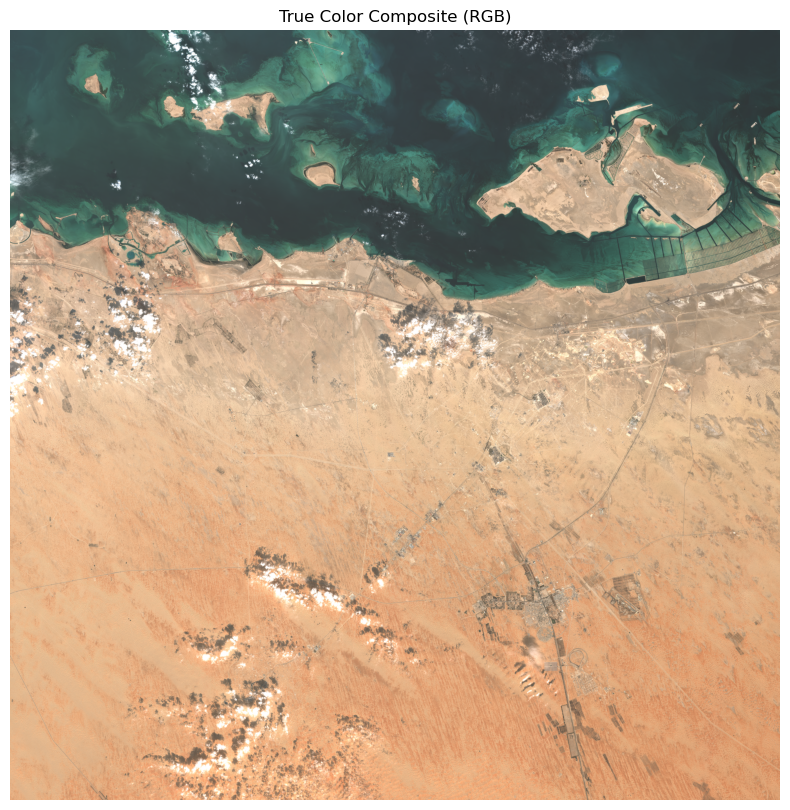

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# B04, B03, B02
rgb = np.dstack([
    bands[3],   # B04 Red
    bands[2],   # B03 Green
    bands[1]    # B02 Blue
])

rgb = rgb.astype(float)
rgb = rgb / np.percentile(rgb, 98)

rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(10,10))
plt.imshow(rgb)
plt.title("True Color Composite (RGB)")
plt.axis('off')
plt.show()

In [30]:
plt.imsave("True_Color.png", rgb)

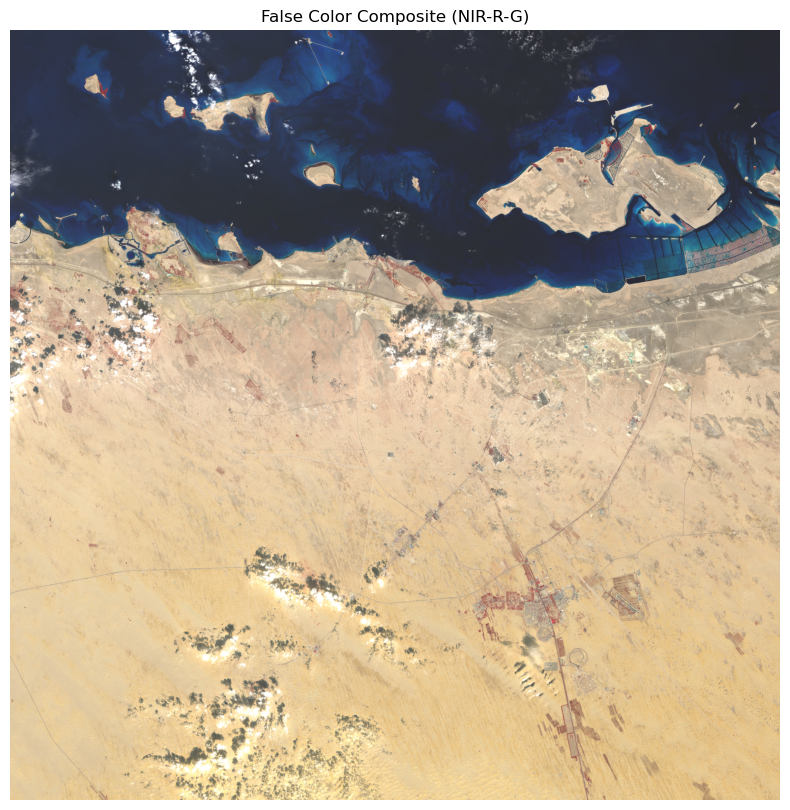

In [31]:
fcc = np.dstack([
    bands[7],   # B8A (NIR)
    bands[3],   # B04
    bands[2]    # B03
])

fcc = fcc.astype(float)
fcc = fcc / np.percentile(fcc, 98)

fcc = np.clip(fcc, 0, 1)

plt.figure(figsize=(10,10))
plt.imshow(fcc)
plt.title("False Color Composite (NIR-R-G)")
plt.axis('off')
plt.show()

In [32]:
plt.imsave("False_Color.png", fcc)

In [38]:
red   = bands[3]/10000
green = bands[2]/10000
blue  = bands[1]/10000

In [39]:
red   = np.clip(bands[3]/10000,0,1)
green = np.clip(bands[2]/10000,0,1)
blue  = np.clip(bands[1]/10000,0,1)

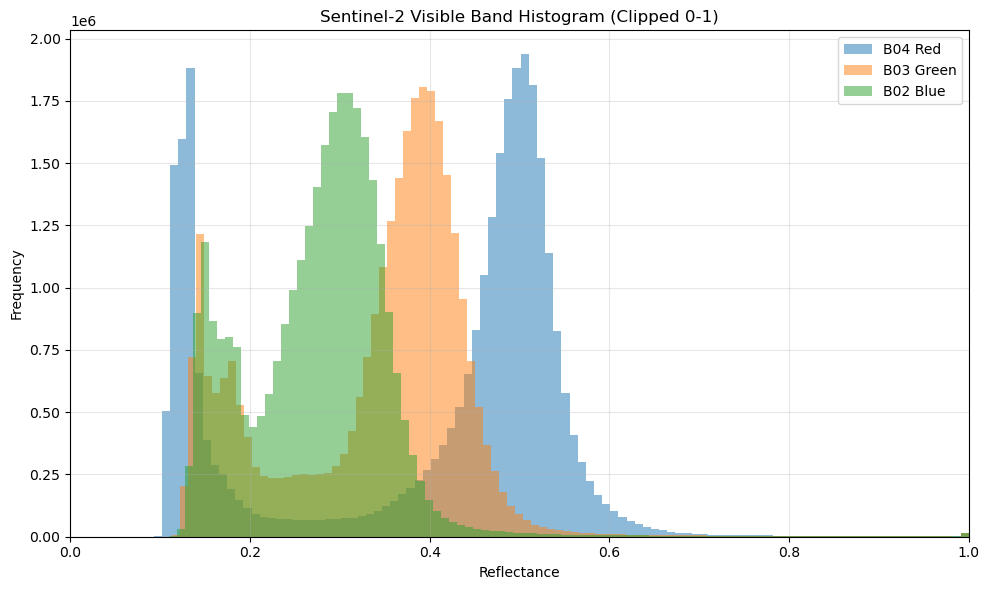

In [41]:
# Histogram of Reflectance Values for Your Three Classes
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    red.ravel(),
    bins=100,
    alpha=0.5,
    label='B04 Red'
)

plt.hist(
    green.ravel(),
    bins=100,
    alpha=0.5,
    label='B03 Green'
)

plt.hist(
    blue.ravel(),
    bins=100,
    alpha=0.5,
    label='B02 Blue'
)

plt.xlim(0, 1)

plt.xlabel("Reflectance")
plt.ylabel("Frequency")
plt.title("Sentinel-2 Visible Band Histogram (Clipped 0-1)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()